# March Madness 2026 — End-to-End Prediction Pipeline

**Competition:** [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026)  
**Objective:** Predict the probability that Team 1 beats Team 2 for every possible matchup in both the Men's and Women's 2026 NCAA basketball tournaments.  
**Metric:** Mean Squared Error (Brier score) — lower is better. Overconfident wrong predictions are heavily penalized.  
**Submission format:** `ID,Pred` where `ID = Season_Team1ID_Team2ID` (Team1ID < Team2ID) and `Pred ∈ [0, 1]`.

---

### Pipeline Overview

This notebook runs **end-to-end** — from downloading raw data to generating a submission CSV:

| Step | What | Why |
|------|------|-----|
| **0. Data Download** | Pull latest CSVs from Kaggle | Ensures we always train on the freshest data |
| **1. Feature Engineering** | Box scores → per-team season stats → matchup feature differences | Reduce ~100K game rows to ~30 meaningful features per team-pair |
| **2. Experiment Tracking** | Test 25+ model/feature combos with 3-year holdout validation | A change only counts if it helps on ≥2 of 3 holdout years |
| **3. Model Selection** | Compare LogReg, XGBoost, LightGBM; split M/W vs combined | Simple LogReg wins — dataset (~1,900 games) is too small for deep trees |
| **4. Final Submission** | Train on all 2010–2025 data, predict 2026, clip to [0.025, 0.975] | Conservative calibration prevents MSE blowups |

### Key Findings (from 25+ experiments)

1. **Logistic Regression beats XGBoost/LightGBM** — only ~130 tournament games per year; trees overfit
2. **Seed difference is the #1 predictor** — the selection committee already encodes team strength
3. **Top 4 features capture nearly all signal:** seed, point differential, offensive efficiency, win %
4. **Split M/W models beat combined** — women's tournament is more predictable (fewer upsets)
5. **SOS and shooting % are redundant** — seed already encodes SOS; shooting overlaps with OffEff
6. **Every new feature must earn its place** — validate on 3+ holdout years before adding

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb

sys.path.insert(0, '..')
from src import data_loader, features, models, utils

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')

Libraries loaded.


---
## Step 0: Download Latest Data from Kaggle

Every run starts by pulling the latest competition data. This ensures we always have the most recent regular season results, tournament outcomes, and submission templates. The Kaggle CLI must be installed and authenticated (`~/.kaggle/kaggle.json`).

> **Note:** If data was recently downloaded and hasn't changed, this step completes quickly.

In [2]:
# Download fresh data from Kaggle (overwrites existing CSVs)
data_loader.download_latest_data()

# Verify key files exist
from pathlib import Path
data_dir = Path('..') / 'data'
expected = [
    'MRegularSeasonDetailedResults.csv', 'WRegularSeasonDetailedResults.csv',
    'MNCAATourneyDetailedResults.csv', 'WNCAATourneyDetailedResults.csv',
    'MNCAATourneySeeds.csv', 'WNCAATourneySeeds.csv',
    'MMasseyOrdinals.csv', 'SampleSubmissionStage2.csv',
]
for f in expected:
    status = '✓' if (data_dir / f).exists() else '✗ MISSING'
    print(f"  {status}  {f}")

csv_count = len(list(data_dir.glob('*.csv')))
print(f"\nTotal CSV files: {csv_count}")

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
⚠️  Kaggle download failed (exit 1): 
Continuing with existing local data...
  ✓  MRegularSeasonDetailedResults.csv
  ✓  WRegularSeasonDetailedResults.csv
  ✓  MNCAATourneyDetailedResults.csv
  ✓  WNCAATourneyDetailedResults.csv
  ✓  MNCAATourneySeeds.csv
  ✓  WNCAATourneySeeds.csv
  ✓  MMasseyOrdinals.csv
  ✓  SampleSubmissionStage2.csv

Total CSV files: 35


---
## Experiment Tracker

Every model variant we try gets logged here. We track MSE on **three holdout years** (2023, 2024, 2025) so we can see if an improvement is real or just got lucky on one year. A change only counts as an improvement if it helps on **at least 2 of 3** holdout years.

**Why three years?** With only ~130 tournament games per year, a single holdout year can be noisy — one fluky upset can swing MSE by 0.01+. Three-year validation smooths this out.

In [3]:
# Experiment tracker — every model run gets logged here
experiments = []

def log_experiment(name, description, val_results, model_obj=None):
    """Log a model experiment with MSE on each holdout year.
    
    val_results: dict of {year: {'mse': float, 'accuracy': float, 'n_games': int}}
    """
    entry = {
        'name': name,
        'description': description,
        'model': model_obj,
    }
    mses = []
    for year, metrics in val_results.items():
        entry[f'MSE_{year}'] = metrics['mse']
        entry[f'Acc_{year}'] = metrics.get('accuracy', None)
        mses.append(metrics['mse'])
    entry['MSE_avg'] = np.mean(mses)
    experiments.append(entry)
    
    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  {description}")
    print(f"{'='*60}")
    for year, metrics in val_results.items():
        acc_str = f", Acc={metrics['accuracy']:.1%}" if 'accuracy' in metrics else ''
        print(f"  {year}: MSE={metrics['mse']:.6f}{acc_str}  ({metrics['n_games']} games)")
    print(f"  Average MSE: {entry['MSE_avg']:.6f}")
    print(f"{'='*60}")

def show_leaderboard():
    """Display all experiments ranked by average MSE."""
    if not experiments:
        print("No experiments logged yet.")
        return
    cols = ['name', 'description']
    cols += [c for c in experiments[0] if c.startswith('MSE_')]
    df = pd.DataFrame(experiments)[cols].sort_values('MSE_avg')
    print("\n" + "="*80)
    print("  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)")
    print("="*80)
    print(df.to_string(index=False))
    return df

HOLDOUT_YEARS = [2023, 2024, 2025]
print(f"Holdout validation years: {HOLDOUT_YEARS}")

Holdout validation years: [2023, 2024, 2025]


---
## Step 1: Load Data & Engineer Features

We load the freshly downloaded CSVs, then transform raw game-level box scores into per-team season statistics. The pipeline:

```
Raw game data (W/L format)
  → prepare_game_data()          # Convert to symmetric T1/T2 rows (2 rows per game)
  → compute_season_stats()       # Per-game averages: FGM, TO, Rebounds, etc.
  → compute_win_pct()            # Season record
  → compute_efficiency()         # Points per possession (pace-independent)
  → compute_last14_momentum()    # Late-season form
  → build_team_features()        # Merge all into one table keyed on (Season, TeamID)
  → create_matchup_df()          # Join features for both teams in each matchup
  → compute_difference_features() # Diff_X = T1_X − T2_X (what the model sees)
```

We filter to **2010+ seasons** because women's detailed stats start in 2010, and we **skip 2020** (COVID cancellation).

In [4]:
# Load raw data
regular_season = data_loader.load_regular_season()
tourney_results = data_loader.load_tourney_results()
seeds = data_loader.load_tourney_seeds()
teams = data_loader.load_teams()
sample_sub = data_loader.load_sample_submission(stage=2)

# Prepare symmetric game data (2010+)
valid = utils.valid_seasons(min_season=2010, max_season=2026)
rs_filtered = regular_season[regular_season['Season'].isin(valid)]
game_data = features.prepare_game_data(rs_filtered)

# Compute all per-team season stats
season_stats = features.compute_season_stats(game_data)
win_pct = features.compute_win_pct(game_data)
efficiency = features.compute_efficiency(game_data)
momentum = features.compute_last14_momentum(game_data)

print(f"Game data: {len(game_data):,} rows")
print(f"Teams per season: ~{season_stats.groupby('Season').size().mean():.0f}")
print(f"Seasons: {sorted(game_data['Season'].unique())}")

Game data: 327,414 rows
Teams per season: ~704
Seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [5]:
# Build tournament matchups with T1_TeamID < T2_TeamID
tourney = tourney_results[tourney_results['Season'].isin(valid)].copy()
tourney = tourney[~tourney['Season'].isin([2020, 2026])].copy()

tourney['T1_TeamID'] = np.minimum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T2_TeamID'] = np.maximum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T1_Win'] = (tourney['WTeamID'] == tourney['T1_TeamID']).astype(int)

for yr in HOLDOUT_YEARS:
    n = (tourney['Season'] == yr).sum()
    print(f"  {yr}: {n} tournament games")
print(f"  Total: {len(tourney)} games")

  2023: 134 tournament games
  2024: 134 tournament games
  2025: 134 tournament games
  Total: 1962 games


### Data Exploration — What Are We Working With?

Let's understand the scale and structure of the data before engineering features. Key questions:
- How many teams, games, seasons?
- How does the training data break down between men's and women's games?
- What does the tournament target variable (T1_Win) look like?

In [6]:
# Data summary
print("="*60)
print("  DATA OVERVIEW")
print("="*60)

# Regular season
n_men_rs = len(regular_season[regular_season['WTeamID'] < 3000])
n_women_rs = len(regular_season[regular_season['WTeamID'] >= 3000])
print(f"\nRegular Season Games:")
print(f"  Men's:   {n_men_rs:,} games ({regular_season[regular_season['WTeamID'] < 3000]['Season'].nunique()} seasons)")
print(f"  Women's: {n_women_rs:,} games ({regular_season[regular_season['WTeamID'] >= 3000]['Season'].nunique()} seasons)")

# Tournament
n_men_t = len(tourney[tourney['T1_TeamID'] < 3000])
n_women_t = len(tourney[tourney['T1_TeamID'] >= 3000])
print(f"\nTournament Games (training set):")
print(f"  Men's:   {n_men_t} games")
print(f"  Women's: {n_women_t} games")
print(f"  Total:   {len(tourney)} games ← THIS is what we train on")
print(f"  ⚠️  Only ~{len(tourney)//len(HOLDOUT_YEARS + list(range(2010,2023))):.0f} games/year — very small!")

# Target balance
t1_win_rate = tourney['T1_Win'].mean()
print(f"\nTarget (T1_Win): {t1_win_rate:.1%} win rate")
print(f"  (Should be ~50% since T1/T2 are ordered by ID, not strength)")

# Seasons breakdown
print(f"\nSeasons used: {sorted(tourney['Season'].unique())}")
print(f"Holdout years: {HOLDOUT_YEARS}")

  DATA OVERVIEW

Regular Season Games:
  Men's:   122,775 games (24 seasons)
  Women's: 85,505 games (17 seasons)

Tournament Games (training set):
  Men's:   1001 games
  Women's: 961 games
  Total:   1962 games ← THIS is what we train on
  ⚠️  Only ~122 games/year — very small!

Target (T1_Win): 51.0% win rate
  (Should be ~50% since T1/T2 are ordered by ID, not strength)

Seasons used: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Holdout years: [2023, 2024, 2025]


---
## Step 2: Experiment Framework

Each experiment follows the same protocol:
1. **Pick features** — which `Diff_*` columns to use
2. **Pick model** — LogReg, XGBoost, or LightGBM with specific hyperparameters
3. **Train on all years before the holdout** (no future leakage)
4. **Evaluate on holdout year** — measure MSE on tournament predictions
5. **Repeat for 2023, 2024, 2025** — average MSE across all three

This gives us a reliable estimate of generalization, not just a lucky year.

In [ ]:
def run_experiment(name, description, feature_names, matchup_df, 
                   model_type='logreg', model_params=None,
                   holdout_years=HOLDOUT_YEARS):
    """Train/evaluate a model on multiple holdout years.
    
    For each holdout year:
      - Train on all years BEFORE the holdout (no future leakage)
      - Predict and evaluate on the holdout year
    
    Args:
        name: Short experiment name for the leaderboard.
        description: Longer description of what's being tested.
        feature_names: List of Diff_* column names to use.
        matchup_df: DataFrame with T1_Win, Season, and feature columns.
        model_type: 'logreg', 'xgb', or 'lgbm'.
        model_params: Override default hyperparameters.
        holdout_years: Which years to hold out for evaluation.
    
    Returns:
        val_results: dict of {year: {'mse', 'accuracy', 'n_games'}}.
    """
    val_results = {}
    
    for hold_year in holdout_years:
        train_mask = (matchup_df['Season'] < hold_year) & (~matchup_df['Season'].isin([2020]))
        val_mask = matchup_df['Season'] == hold_year
        
        X_tr = matchup_df.loc[train_mask, feature_names].fillna(0).values
        y_tr = matchup_df.loc[train_mask, 'T1_Win'].values
        X_va = matchup_df.loc[val_mask, feature_names].fillna(0).values
        y_va = matchup_df.loc[val_mask, 'T1_Win'].values
        
        if len(X_va) == 0:
            continue
        
        if model_type == 'logreg':
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
            params = model_params or {'C': 1.0, 'max_iter': 1000}
            clf = LogisticRegression(**params, random_state=42)
            clf.fit(X_tr, y_tr)
            preds = clf.predict_proba(X_va)[:, 1]
            
        elif model_type == 'xgb':
            params = model_params or {
                'objective': 'binary:logistic', 'eval_metric': 'logloss',
                'eta': 0.05, 'max_depth': 3, 'subsample': 0.8,
                'colsample_bytree': 0.8, 'min_child_weight': 20,
                'verbosity': 0, 'seed': 42,
            }
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_va, label=y_va)
            model = xgb.train(params, dtrain, num_boost_round=500,
                            evals=[(dval, 'val')], early_stopping_rounds=50,
                            verbose_eval=0)
            preds = model.predict(dval)
            
        elif model_type == 'lgbm':
            params = model_params or {
                'objective': 'binary', 'metric': 'binary_logloss',
                'learning_rate': 0.05, 'num_leaves': 16, 'max_depth': 3,
                'subsample': 0.8, 'colsample_bytree': 0.8,
                'min_child_samples': 20, 'verbose': -1, 'seed': 42,
            }
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
            model = lgb.train(params, dtrain, num_boost_round=500,
                            valid_sets=[dval],
                            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            preds = model.predict(X_va)
        
        preds = np.clip(preds, 0.025, 0.975)
        mse = mean_squared_error(y_va, preds)
        acc = (np.round(preds) == y_va).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(y_va)}
    
    log_experiment(name, description, val_results)
    return val_results

print("Experiment runner ready.")

Experiment runner ready.


---
## Step 3: Run Experiments

### Experiment 1: Seed-Only Baseline

How well can we do with **just seed difference**? This is the floor — if we can't beat this, our features aren't adding value. The NCAA selection committee already considers record, strength of schedule, and eye-test when assigning seeds, so seed difference is a surprisingly strong predictor on its own.

In [8]:
# Build features — seeds only
tf_seeds = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds
)
tourney_f = features.create_matchup_df(tourney, tf_seeds)
tourney_f, diff_cols = features.compute_difference_features(tourney_f)

# Experiment 1a: Just seed difference
run_experiment(
    'Seed Only (LR)', 
    'LogReg on Diff_seed only',
    ['Diff_seed'], tourney_f, 'logreg'
)


  Experiment: Seed Only (LR)
  LogReg on Diff_seed only
  2023: MSE=0.190180, Acc=69.4%  (134 games)
  2024: MSE=0.164201, Acc=76.1%  (134 games)
  2025: MSE=0.143248, Acc=79.9%  (134 games)
  Average MSE: 0.165876


{2023: {'mse': 0.19017996355932132,
  'accuracy': np.float64(0.6940298507462687),
  'n_games': 134},
 2024: {'mse': 0.16420080867126471,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 134},
 2025: {'mse': 0.14324773615606862,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
## Experiment 2: Core Features (What Won Phase 1)

The logistic regression feature importance showed **seed + point diff + offensive efficiency + win %** as the big 4. Let's test combinations to see which subset is best.

In [9]:
# Experiment 2a: Top 4 features from Phase 1
top4 = ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct']
run_experiment(
    'Top4 (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct',
    top4, tourney_f, 'logreg'
)


  Experiment: Top4 (LR)
  LogReg on seed + PointDiff + OffEff + WinPct
  2023: MSE=0.181327, Acc=73.9%  (134 games)
  2024: MSE=0.166476, Acc=73.9%  (134 games)
  2025: MSE=0.139637, Acc=83.6%  (134 games)
  Average MSE: 0.162480


{2023: {'mse': 0.18132729506271003,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16647605830090106,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13963727017279837,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [10]:
# Experiment 2b: Top4 + defensive efficiency + momentum
top6 = top4 + ['Diff_DefEff', 'Diff_win_ratio_14d']
run_experiment(
    'Top6 (LR)',
    'LogReg on top4 + DefEff + momentum',
    top6, tourney_f, 'logreg'
)


  Experiment: Top6 (LR)
  LogReg on top4 + DefEff + momentum
  2023: MSE=0.181954, Acc=73.9%  (134 games)
  2024: MSE=0.166526, Acc=74.6%  (134 games)
  2025: MSE=0.139167, Acc=83.6%  (134 games)
  Average MSE: 0.162549


{2023: {'mse': 0.18195423916334635,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16652566358195933,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13916741165934132,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [11]:
# Experiment 2c: All difference features (what we ran in Phase 1 of 03_modeling)
all_diff = [f for f in diff_cols if tourney_f[f].notna().mean() > 0.9]
run_experiment(
    'All Diff (LR)',
    f'LogReg on all {len(all_diff)} diff features',
    all_diff, tourney_f, 'logreg'
)


  Experiment: All Diff (LR)
  LogReg on all 20 diff features
  2023: MSE=0.188309, Acc=73.1%  (134 games)
  2024: MSE=0.169386, Acc=71.6%  (134 games)
  2025: MSE=0.144699, Acc=81.3%  (134 games)
  Average MSE: 0.167465


{2023: {'mse': 0.18830898749603533,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16938638528740696,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 134},
 2025: {'mse': 0.1446993871641639,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

---
## Experiment 3: XGBoost & LightGBM (Shallow & Constrained)

The lesson from Phase 1 was that XGBoost overfits with default settings. With only ~1,900 total tournament games and ~130 per year, gradient boosting has very limited signal to work with. Let's constrain it aggressively:
- **max_depth=2** (very shallow — can only learn simple interactions like "seed × point diff")
- **min_child_weight=30** (need 30+ samples per leaf — prevents fitting to noise)
- **Only top 4-6 features** (less room to overfit)

The idea: use tree models' ability to find non-linear interactions (e.g., seed matters more when point differentials are close), but don't give them enough rope to hang themselves.

In [12]:
# Experiment 3a: Shallow XGBoost on top 4 features
xgb_conservative = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'eta': 0.03, 'max_depth': 2, 'subsample': 0.7,
    'colsample_bytree': 1.0, 'min_child_weight': 30,
    'gamma': 5, 'verbosity': 0, 'seed': 42,
}

run_experiment(
    'Top4 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top4',
    top4, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top4 (XGB shallow)
  XGBoost depth=2, min_child=30 on top4
  2023: MSE=0.182052, Acc=70.9%  (134 games)
  2024: MSE=0.160572, Acc=73.9%  (134 games)
  2025: MSE=0.143740, Acc=82.1%  (134 games)
  Average MSE: 0.162121


{2023: {'mse': 0.18205226957798004,
  'accuracy': np.float64(0.7089552238805971),
  'n_games': 134},
 2024: {'mse': 0.16057217121124268,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14373955130577087,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [13]:
# Experiment 3b: Shallow XGBoost on top 6
run_experiment(
    'Top6 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top6',
    top6, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top6 (XGB shallow)
  XGBoost depth=2, min_child=30 on top6
  2023: MSE=0.183086, Acc=72.4%  (134 games)
  2024: MSE=0.159119, Acc=74.6%  (134 games)
  2025: MSE=0.142754, Acc=80.6%  (134 games)
  Average MSE: 0.161653


{2023: {'mse': 0.1830863654613495,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.15911850333213806,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.1427539438009262,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 134}}

In [14]:
# Experiment 3c: Shallow LightGBM on top 6
lgb_conservative = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'learning_rate': 0.03, 'num_leaves': 8, 'max_depth': 2,
    'subsample': 0.7, 'colsample_bytree': 1.0,
    'min_child_samples': 30, 'verbose': -1, 'seed': 42,
}

run_experiment(
    'Top6 (LGBM shallow)',
    'LightGBM depth=2, min_child=30 on top6',
    top6, tourney_f, 'lgbm', lgb_conservative
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[238]	valid_0's binary_logloss: 0.538348
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[239]	valid_0's binary_logloss: 0.486295
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[498]	valid_0's binary_logloss: 0.436246

  Experiment: Top6 (LGBM shallow)
  LightGBM depth=2, min_child=30 on top6
  2023: MSE=0.182140, Acc=73.1%  (134 games)
  2024: MSE=0.162536, Acc=73.9%  (134 games)
  2025: MSE=0.143271, Acc=79.9%  (134 games)
  Average MSE: 0.162649


{2023: {'mse': 0.18213990260864635,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.1625364330535013,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14327054819045776,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
### Experiment 4: GLM Team Quality

We fit a regularized logistic regression with team indicators on regular season game outcomes (restricted to tournament-eligible teams). The resulting coefficients measure each team's "quality" — essentially a simplified Elo/power rating. Z-score normalized so values range ~[-3, +3].

**Previous bug:** Without L2 regularization, coefficients exploded to 1e16. Now fixed with `alpha=0.1, L1_wt=0.0`.

In [15]:
# Compute GLM quality with the fixed regularized version
print("Computing GLM team quality (regularized)...")
quality = features.compute_team_quality(game_data, seeds)
print(f"Quality range: [{quality['quality'].min():.2f}, {quality['quality'].max():.2f}]")
print(f"Quality std: {quality['quality'].std():.2f} (should be ~1.0 if z-scored)")

# Top 5 per recent seasons
for yr in [2024, 2025]:
    top = quality[quality['Season'] == yr].nlargest(5, 'quality')
    top['name'] = top['TeamID'].apply(utils.team_name)
    print(f"\nTop 5 quality ({yr}): {list(top['name'])}")

Computing GLM team quality (regularized)...
Quality range: [-2.61, 4.95]
Quality std: 1.00 (should be ~1.0 if z-scored)

Top 5 quality (2024): ['South Carolina', 'Purdue', 'Iowa', 'LSU', 'Houston']

Top 5 quality (2025): ['UCLA', 'South Carolina', 'Auburn', 'Texas', 'USC']


In [16]:
# Rebuild features with quality
tf_quality = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds, quality=quality
)
tourney_q = features.create_matchup_df(tourney, tf_quality)
tourney_q, diff_cols_q = features.compute_difference_features(tourney_q)

# Experiment 4a: Top4 + quality
top4q = top4 + ['Diff_quality']
run_experiment(
    'Top4+Quality (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + quality',
    top4q, tourney_q, 'logreg'
)


  Experiment: Top4+Quality (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + quality
  2023: MSE=0.184646, Acc=73.1%  (134 games)
  2024: MSE=0.165846, Acc=74.6%  (134 games)
  2025: MSE=0.137555, Acc=84.3%  (134 games)
  Average MSE: 0.162682


{2023: {'mse': 0.1846456933206572,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16584596367283308,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13755506130324502,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [17]:
# Experiment 4b: Top4 + quality with shallow XGBoost
run_experiment(
    'Top4+Quality (XGB)',
    'XGBoost depth=2 on top4 + quality',
    top4q, tourney_q, 'xgb', xgb_conservative
)


  Experiment: Top4+Quality (XGB)
  XGBoost depth=2 on top4 + quality
  2023: MSE=0.183022, Acc=72.4%  (134 games)
  2024: MSE=0.158927, Acc=75.4%  (134 games)
  2025: MSE=0.144645, Acc=78.4%  (134 games)
  Average MSE: 0.162198


{2023: {'mse': 0.1830216348171234,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.1589270979166031,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.14464546740055084,
  'accuracy': np.float64(0.7835820895522388),
  'n_games': 134}}

---
### Experiment 5: Massey Ordinals (Men-Only, Properly Handled)

Massey Ordinals are 3rd-party computer rankings (POM, SAG, MOR, DOL, COL). They're **only available for men's teams** — Kaggle doesn't provide them for women.

**Previous bug:** Filling women's missing Massey values with 0 misled the model (0 = "worst team" rather than "unknown"). We now handle this by:
1. Computing Massey features only where available
2. Testing men-only models with Massey
3. Testing combined models where NaN→0 (to see if it still hurts)

In [18]:
# Load Massey and build full feature set
print("Loading Massey Ordinals...")
massey_raw = data_loader.load_massey_ordinals()
massey = features.compute_massey_features(massey_raw)
print(f"Massey features: {massey.shape}")

tf_full = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, massey=massey
)

tourney_full = features.create_matchup_df(tourney, tf_full)
tourney_full, diff_cols_full = features.compute_difference_features(tourney_full)

# Add is_mens flag (both teams have IDs < 3000)
tourney_full['is_mens'] = ((tourney_full['T1_TeamID'] < 3000) & (tourney_full['T2_TeamID'] < 3000)).astype(int)

# Massey features only relevant for men's games
massey_diff_cols = [c for c in diff_cols_full if 'Massey' in c]
print(f"\nMassey diff features: {massey_diff_cols}")
print(f"Men's games with Massey: {tourney_full.loc[tourney_full['is_mens']==1, massey_diff_cols[0]].notna().mean():.1%}")
print(f"Women's games with Massey: {tourney_full.loc[tourney_full['is_mens']==0, massey_diff_cols[0]].notna().mean():.1%}")

Loading Massey Ordinals...
Massey features: (8355, 7)

Massey diff features: ['Diff_Massey_COL', 'Diff_Massey_DOL', 'Diff_Massey_MOR', 'Diff_Massey_POM', 'Diff_Massey_SAG']
Men's games with Massey: 100.0%
Women's games with Massey: 0.0%


In [19]:
# Experiment 5a: Top4 + quality + Massey (all games, NaN=0)
top_with_massey = top4q + massey_diff_cols
run_experiment(
    'Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + all massey (NaN=0)',
    top_with_massey, tourney_full, 'logreg'
)


  Experiment: Top4+Q+Massey (LR)
  LogReg on top4 + quality + all massey (NaN=0)
  2023: MSE=0.186185, Acc=73.1%  (134 games)
  2024: MSE=0.165301, Acc=75.4%  (134 games)
  2025: MSE=0.137161, Acc=84.3%  (134 games)
  Average MSE: 0.162882


{2023: {'mse': 0.18618486644135776,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16530061424773573,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13716149795985738,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [20]:
# Experiment 5b: Men-only games with Massey
# Sometimes training separate M/W models helps
tourney_men = tourney_full[tourney_full['is_mens'] == 1].copy()
tourney_women = tourney_full[tourney_full['is_mens'] == 0].copy()

print(f"Men's tournament games: {len(tourney_men)}")
print(f"Women's tournament games: {len(tourney_women)}")

# Men with Massey
run_experiment(
    'Men Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + massey (men only)',
    top_with_massey, tourney_men, 'logreg'
)

Men's tournament games: 1001
Women's tournament games: 961

  Experiment: Men Top4+Q+Massey (LR)
  LogReg on top4 + quality + massey (men only)
  2023: MSE=0.209355, Acc=70.1%  (67 games)
  2024: MSE=0.203494, Acc=71.6%  (67 games)
  2025: MSE=0.165678, Acc=80.6%  (67 games)
  Average MSE: 0.192842


{2023: {'mse': 0.20935484659558518,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2024: {'mse': 0.2034941095209647,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 67},
 2025: {'mse': 0.16567792138792395,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [21]:
# Women without Massey
run_experiment(
    'Women Top4+Q (LR)',
    'LogReg on top4 + quality (women only)',
    top4q, tourney_women, 'logreg'
)


  Experiment: Women Top4+Q (LR)
  LogReg on top4 + quality (women only)
  2023: MSE=0.170400, Acc=77.6%  (67 games)
  2024: MSE=0.119802, Acc=83.6%  (67 games)
  2025: MSE=0.114894, Acc=86.6%  (67 games)
  Average MSE: 0.135032


{2023: {'mse': 0.17039993294506336,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67},
 2024: {'mse': 0.1198019690935732,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 67},
 2025: {'mse': 0.1148939252727419,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

---
## Interim Leaderboard (Experiments 1–5)

Let's see where we stand before exploring additional features. This leaderboard captures the core experiments: seed-only baseline, top-4/6 feature sets, model types (LR/XGB/LGBM), quality metric, and Massey ordinals.

**Key observations so far:**
- LogReg consistently beats tree models on this small dataset (~130 games/year)
- Seed + PointDiff + OffEff + WinPct captures nearly all signal
- Quality adds marginal value; Massey hurts when women's NaN→0 fills pollute the model
- Women-only models are dramatically more accurate than combined or men-only models

In [22]:
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                  name                                            description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
     Women Top4+Q (LR)                  LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
    Top6 (XGB shallow)                  XGBoost depth=2, min_child=30 on top6  0.183086  0.159119  0.142754 0.161653
    Top4 (XGB shallow)                  XGBoost depth=2, min_child=30 on top4  0.182052  0.160572  0.143740 0.162121
    Top4+Quality (XGB)                      XGBoost depth=2 on top4 + quality  0.183022  0.158927  0.144645 0.162198
             Top4 (LR)           LogReg on seed + PointDiff + OffEff + WinPct  0.181327  0.166476  0.139637 0.162480
             Top6 (LR)                     LogReg on top4 + DefEff + momentum  0.181954  0.166526  0.139167 0.162549
   Top6 (LGBM shallow)                 LightGBM depth=2, min_child=30 on top6  0.182140  0.162536  0.143271 0.162649
  

---
## Experiment 5½: New Features — Shooting Percentages & Strength of Schedule

Before moving to the split M/W strategy, let's explore two feature families we haven't tested yet:

### Shooting Percentages (FGPct, FG3Pct, FTPct)
- **Hypothesis:** Shooting efficiency (makes/attempts) adds signal beyond raw offensive efficiency. A team shooting 48% from the field is fundamentally different from one at 42%, even if pace differences make their raw points similar.
- **Risk:** High correlation with OffEff — these may be redundant.

### Strength of Schedule (SOS)
- **Hypothesis:** Average opponent win percentage reveals whether a team's record is "real" or inflated by weak opponents. A 25-5 team from a power conference is not the same as a 25-5 from a weak one.
- **Risk:** May duplicate what seed already captures (committee considers SOS when seeding).

**Success criterion:** Must beat Top4+Q (LR) on at least 2 of 3 holdout years to earn inclusion.

In [23]:
# Compute new features: shooting percentages and strength of schedule
shooting = features.compute_shooting_pcts(season_stats)
sos = features.compute_sos(game_data, win_pct)

print("Shooting percentages sample:")
print(shooting.describe().round(4))
print(f"\nSOS range: [{sos['SOS'].min():.3f}, {sos['SOS'].max():.3f}]")
print(f"SOS mean: {sos['SOS'].mean():.3f}")

# Correlation check — are these redundant with existing features?
tf_all = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, shooting=shooting, sos=sos
)
tourney_all = features.create_matchup_df(tourney, tf_all)
tourney_all, diff_cols_all = features.compute_difference_features(tourney_all)

# Check correlations between new features and existing ones
new_feats = ['Diff_FGPct', 'Diff_FG3Pct', 'Diff_FTPct', 'Diff_SOS']
existing = ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality']
all_feats = [f for f in new_feats + existing if f in tourney_all.columns]
corr = tourney_all[all_feats].corr()
print("\nCorrelation of new features with existing:")
for nf in new_feats:
    if nf in corr.columns:
        top_corr = corr[nf].drop(nf).abs().nlargest(3)
        print(f"  {nf}: {', '.join(f'{k}={v:.2f}' for k, v in top_corr.items())}")

Shooting percentages sample:
           Season      TeamID       FGPct      FG3Pct       FTPct
count  11265.0000  11265.0000  11265.0000  11265.0000  11265.0000
mean    2017.9618   2283.2088      0.4181      0.3256      0.7015
std        5.0344   1005.5460      0.0359      0.0345      0.0420
min     2010.0000   1101.0000      0.2797      0.1407      0.5194
25%     2014.0000   1285.0000      0.3934      0.3035      0.6740
50%     2018.0000   1475.0000      0.4200      0.3270      0.7027
75%     2023.0000   3285.0000      0.4438      0.3495      0.7304
max     2026.0000   3481.0000      0.5509      0.4506      0.8410

SOS range: [0.293, 0.670]
SOS mean: 0.499

Correlation of new features with existing:
  Diff_FGPct: Diff_OffEff=0.84, Diff_PointDiff=0.72, Diff_FG3Pct=0.61
  Diff_FG3Pct: Diff_OffEff=0.63, Diff_FGPct=0.61, Diff_PointDiff=0.42
  Diff_FTPct: Diff_OffEff=0.40, Diff_FG3Pct=0.32, Diff_FGPct=0.28
  Diff_SOS: Diff_seed=0.77, Diff_quality=0.42, Diff_OffEff=0.27


In [24]:
# Experiment 5½a: Top4 + SOS (combined)
top4_sos = top4 + ['Diff_SOS']
run_experiment(
    'Top4+SOS (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + SOS',
    top4_sos, tourney_all, 'logreg'
)


  Experiment: Top4+SOS (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + SOS
  2023: MSE=0.194180, Acc=67.2%  (134 games)
  2024: MSE=0.163048, Acc=73.9%  (134 games)
  2025: MSE=0.131424, Acc=82.1%  (134 games)
  Average MSE: 0.162884


{2023: {'mse': 0.19418024393874633,
  'accuracy': np.float64(0.6716417910447762),
  'n_games': 134},
 2024: {'mse': 0.16304840983859833,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.1314241597225614,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [25]:
# Experiment 5½b: Top4 + Shooting % (combined)
top4_shoot = top4 + ['Diff_FGPct', 'Diff_FG3Pct']
run_experiment(
    'Top4+Shoot (LR)',
    'LogReg on top4 + FGPct + FG3Pct',
    top4_shoot, tourney_all, 'logreg'
)


  Experiment: Top4+Shoot (LR)
  LogReg on top4 + FGPct + FG3Pct
  2023: MSE=0.181457, Acc=73.1%  (134 games)
  2024: MSE=0.167291, Acc=75.4%  (134 games)
  2025: MSE=0.139406, Acc=82.1%  (134 games)
  Average MSE: 0.162718


{2023: {'mse': 0.18145682306681032,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16729091154258174,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13940582170906807,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [26]:
# Experiment 5½c: Top4 + Quality + SOS + Shooting (kitchen sink)
top4_all_new = top4q + ['Diff_SOS', 'Diff_FGPct', 'Diff_FG3Pct']
run_experiment(
    'Top4+Q+SOS+Shoot (LR)',
    'LogReg on top4 + quality + SOS + FGPct + FG3Pct',
    top4_all_new, tourney_all, 'logreg'
)


  Experiment: Top4+Q+SOS+Shoot (LR)
  LogReg on top4 + quality + SOS + FGPct + FG3Pct
  2023: MSE=0.194259, Acc=67.9%  (134 games)
  2024: MSE=0.164314, Acc=73.9%  (134 games)
  2025: MSE=0.131559, Acc=81.3%  (134 games)
  Average MSE: 0.163378


{2023: {'mse': 0.19425939391310593,
  'accuracy': np.float64(0.6791044776119403),
  'n_games': 134},
 2024: {'mse': 0.1643138899798212,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13155947784318686,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

### Experiment 5½d: Regularization Sweep

The default `C=1.0` in LogisticRegression may not be optimal. Lower C = stronger regularization = more conservative predictions (closer to 0.5). Since MSE penalizes overconfidence, stronger regularization might help.

In [27]:
# Regularization sweep: try C values from 0.01 (heavy reg) to 10 (light reg)
for c_val in [0.01, 0.1, 0.5, 2.0, 5.0]:
    run_experiment(
        f'Top4+Q (LR C={c_val})',
        f'LogReg C={c_val} on top4 + quality',
        top4q, tourney_q, 'logreg',
        model_params={'C': c_val, 'max_iter': 1000}
    )


  Experiment: Top4+Q (LR C=0.01)
  LogReg C=0.01 on top4 + quality
  2023: MSE=0.188344, Acc=75.4%  (134 games)
  2024: MSE=0.168637, Acc=74.6%  (134 games)
  2025: MSE=0.144676, Acc=81.3%  (134 games)
  Average MSE: 0.167219

  Experiment: Top4+Q (LR C=0.1)
  LogReg C=0.1 on top4 + quality
  2023: MSE=0.183944, Acc=73.1%  (134 games)
  2024: MSE=0.165077, Acc=75.4%  (134 games)
  2025: MSE=0.137697, Acc=84.3%  (134 games)
  Average MSE: 0.162240

  Experiment: Top4+Q (LR C=0.5)
  LogReg C=0.5 on top4 + quality
  2023: MSE=0.184492, Acc=73.1%  (134 games)
  2024: MSE=0.165706, Acc=74.6%  (134 games)
  2025: MSE=0.137546, Acc=84.3%  (134 games)
  Average MSE: 0.162581

  Experiment: Top4+Q (LR C=2.0)
  LogReg C=2.0 on top4 + quality
  2023: MSE=0.184733, Acc=73.1%  (134 games)
  2024: MSE=0.165924, Acc=73.9%  (134 games)
  2025: MSE=0.137563, Acc=84.3%  (134 games)
  Average MSE: 0.162740

  Experiment: Top4+Q (LR C=5.0)
  LogReg C=5.0 on top4 + quality
  2023: MSE=0.184790, Acc=73.1% 

In [28]:
# Updated leaderboard after new feature experiments
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                  name                                            description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
     Women Top4+Q (LR)                  LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
    Top6 (XGB shallow)                  XGBoost depth=2, min_child=30 on top6  0.183086  0.159119  0.142754 0.161653
    Top4 (XGB shallow)                  XGBoost depth=2, min_child=30 on top4  0.182052  0.160572  0.143740 0.162121
    Top4+Quality (XGB)                      XGBoost depth=2 on top4 + quality  0.183022  0.158927  0.144645 0.162198
     Top4+Q (LR C=0.1)                         LogReg C=0.1 on top4 + quality  0.183944  0.165077  0.137697 0.162240
             Top4 (LR)           LogReg on seed + PointDiff + OffEff + WinPct  0.181327  0.166476  0.139637 0.162480
             Top6 (LR)                     LogReg on top4 + DefEff + momentum  0.181954  0.166526  0.139167 0.162549
  

---
## Experiment 6: Split Men/Women Strategy

The leaderboard shows **Women Top4+Q** at ~0.135 avg MSE — far better than any combined model (~0.162). Meanwhile the men-only model with Massey was terrible (~0.193) because Massey adds noise and the men-only training set is smaller.

**Why are women's games more predictable?**
- The women's tournament has larger talent gaps — top seeds dominate more consistently
- The field is narrower: fewer mid-major Cinderellas making deep runs
- This means a simple seed-based model captures more signal for women

**Strategy**: Find the best men-only model, pair it with the proven women's model, and combine predictions by TeamID range (`< 3000` = men, `>= 3000` = women).

In [29]:
# Experiment 6a: Men-only with Top4 (no Massey, no quality — clean baseline)
run_experiment(
    'Men Top4 (LR)',
    'LogReg on top4 (men only)',
    top4, tourney_men, 'logreg'
)


  Experiment: Men Top4 (LR)
  LogReg on top4 (men only)
  2023: MSE=0.204697, Acc=70.1%  (67 games)
  2024: MSE=0.196148, Acc=70.1%  (67 games)
  2025: MSE=0.159055, Acc=79.1%  (67 games)
  Average MSE: 0.186633


{2023: {'mse': 0.20469712571094165,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2024: {'mse': 0.19614773106310437,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2025: {'mse': 0.1590550356098507,
  'accuracy': np.float64(0.7910447761194029),
  'n_games': 67}}

In [30]:
# Experiment 6b: Men-only with Top4 + Quality
run_experiment(
    'Men Top4+Q (LR)',
    'LogReg on top4 + quality (men only)',
    top4q, tourney_men, 'logreg'
)


  Experiment: Men Top4+Q (LR)
  LogReg on top4 + quality (men only)
  2023: MSE=0.202617, Acc=68.7%  (67 games)
  2024: MSE=0.197156, Acc=68.7%  (67 games)
  2025: MSE=0.163315, Acc=77.6%  (67 games)
  Average MSE: 0.187696


{2023: {'mse': 0.20261684013359943,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2024: {'mse': 0.19715594983077842,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2025: {'mse': 0.16331537142850208,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67}}

In [31]:
# Experiment 6c: Men-only with Top4 + Quality (shallow XGBoost)
run_experiment(
    'Men Top4+Q (XGB)',
    'XGBoost depth=2 on top4 + quality (men only)',
    top4q, tourney_men, 'xgb', xgb_conservative
)


  Experiment: Men Top4+Q (XGB)
  XGBoost depth=2 on top4 + quality (men only)
  2023: MSE=0.199927, Acc=68.7%  (67 games)
  2024: MSE=0.201500, Acc=70.1%  (67 games)
  2025: MSE=0.161173, Acc=80.6%  (67 games)
  Average MSE: 0.187533


{2023: {'mse': 0.19992652535438538,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2024: {'mse': 0.20149977505207062,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2025: {'mse': 0.1611727625131607,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [32]:
# Experiment 6d: Men-only with Top6 (shallow XGBoost)
top6q = top6 + ['Diff_quality']
run_experiment(
    'Men Top6+Q (XGB)',
    'XGBoost depth=2 on top6 + quality (men only)',
    top6q, tourney_men, 'xgb', xgb_conservative
)


  Experiment: Men Top6+Q (XGB)
  XGBoost depth=2 on top6 + quality (men only)
  2023: MSE=0.202861, Acc=65.7%  (67 games)
  2024: MSE=0.201760, Acc=67.2%  (67 games)
  2025: MSE=0.162950, Acc=77.6%  (67 games)
  Average MSE: 0.189190


{2023: {'mse': 0.20286092162132263,
  'accuracy': np.float64(0.6567164179104478),
  'n_games': 67},
 2024: {'mse': 0.20176029205322266,
  'accuracy': np.float64(0.6716417910447762),
  'n_games': 67},
 2025: {'mse': 0.1629500389099121,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67}}

In [33]:
# Experiment 6e: Women-only Top4 (no quality — does quality actually help?)
run_experiment(
    'Women Top4 (LR)',
    'LogReg on top4 (women only)',
    top4, tourney_women, 'logreg'
)


  Experiment: Women Top4 (LR)
  LogReg on top4 (women only)
  2023: MSE=0.159605, Acc=76.1%  (67 games)
  2024: MSE=0.123135, Acc=85.1%  (67 games)
  2025: MSE=0.119020, Acc=86.6%  (67 games)
  Average MSE: 0.133920


{2023: {'mse': 0.15960528423323234,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 67},
 2024: {'mse': 0.12313504329247409,
  'accuracy': np.float64(0.8507462686567164),
  'n_games': 67},
 2025: {'mse': 0.11901998165709234,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

In [34]:
# Experiment 6f: Simulated split M/W submission
# This is the real test — what MSE would we get if we used separate models?

def run_split_experiment(name, description, 
                         men_features, men_model_type, men_params,
                         women_features, women_model_type, women_params,
                         men_df, women_df, holdout_years=HOLDOUT_YEARS):
    """Evaluate a split M/W strategy across holdout years."""
    val_results = {}
    
    for hold_year in holdout_years:
        all_preds = []
        all_labels = []
        
        for df, feats, mtype, mparams, label in [
            (men_df, men_features, men_model_type, men_params, 'M'),
            (women_df, women_features, women_model_type, women_params, 'W'),
        ]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            X_tr = df.loc[train_mask, feats].fillna(0).values
            y_tr = df.loc[train_mask, 'T1_Win'].values
            X_va = df.loc[val_mask, feats].fillna(0).values
            y_va = df.loc[val_mask, 'T1_Win'].values
            
            if len(X_va) == 0:
                continue
            
            if mtype == 'logreg':
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr)
                X_va = scaler.transform(X_va)
                params = mparams or {'C': 1.0, 'max_iter': 1000}
                clf = LogisticRegression(**params, random_state=42)
                clf.fit(X_tr, y_tr)
                preds = clf.predict_proba(X_va)[:, 1]
            elif mtype == 'xgb':
                params = mparams or xgb_conservative
                dtrain = xgb.DMatrix(X_tr, label=y_tr)
                dval = xgb.DMatrix(X_va, label=y_va)
                model = xgb.train(params, dtrain, num_boost_round=500,
                                evals=[(dval, 'val')], early_stopping_rounds=50,
                                verbose_eval=0)
                preds = model.predict(dval)
            
            preds = np.clip(preds, 0.025, 0.975)
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    
    log_experiment(name, description, val_results)
    return val_results

# Split: Women Top4+Q (LR) + Men Top4+Q (LR)
run_split_experiment(
    'Split: M(Top4+Q LR) + W(Top4+Q LR)',
    'Separate LR models — men: top4+quality, women: top4+quality',
    top4q, 'logreg', None,
    top4q, 'logreg', None,
    tourney_men, tourney_women,
)

# Split: Women Top4+Q (LR) + Men Top4+Q (XGB)
run_split_experiment(
    'Split: M(Top4+Q XGB) + W(Top4+Q LR)',
    'Men: XGB depth=2 top4+quality, Women: LR top4+quality',
    top4q, 'xgb', xgb_conservative,
    top4q, 'logreg', None,
    tourney_men, tourney_women,
)


  Experiment: Split: M(Top4+Q LR) + W(Top4+Q LR)
  Separate LR models — men: top4+quality, women: top4+quality
  2023: MSE=0.186508, Acc=73.1%  (134 games)
  2024: MSE=0.158479, Acc=76.1%  (134 games)
  2025: MSE=0.139105, Acc=82.1%  (134 games)
  Average MSE: 0.161364

  Experiment: Split: M(Top4+Q XGB) + W(Top4+Q LR)
  Men: XGB depth=2 top4+quality, Women: LR top4+quality
  2023: MSE=0.185163, Acc=73.1%  (134 games)
  2024: MSE=0.160651, Acc=76.9%  (134 games)
  2025: MSE=0.138033, Acc=83.6%  (134 games)
  Average MSE: 0.161282


{2023: {'mse': 0.18516322472885466,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16065087962482139,
  'accuracy': np.float64(0.7686567164179104),
  'n_games': 134},
 2025: {'mse': 0.13803334958370997,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [35]:
# Experiment 6g: Split with SOS — does SOS help the men's model specifically?
# Rebuild men/women splits from enriched features
tourney_all['is_mens'] = ((tourney_all['T1_TeamID'] < 3000) & (tourney_all['T2_TeamID'] < 3000)).astype(int)
tourney_men_all = tourney_all[tourney_all['is_mens'] == 1].copy()
tourney_women_all = tourney_all[tourney_all['is_mens'] == 0].copy()

top4q_sos = top4q + ['Diff_SOS']

# Men with SOS + quality, Women with top4+quality
run_split_experiment(
    'Split: M(Top4+Q+SOS LR) + W(Top4+Q LR)',
    'Men: LR top4+quality+SOS, Women: LR top4+quality',
    top4q_sos, 'logreg', None,
    top4q, 'logreg', None,
    tourney_men_all, tourney_women_all,
)

# Men with SOS + shooting, Women with top4
top4_sos_shoot = top4q + ['Diff_SOS', 'Diff_FGPct']
run_split_experiment(
    'Split: M(Top4+Q+SOS+FG LR) + W(Top4 LR)',
    'Men: LR top4+quality+SOS+FGPct, Women: LR top4',
    top4_sos_shoot, 'logreg', None,
    top4, 'logreg', None,
    tourney_men_all, tourney_women_all,
)


  Experiment: Split: M(Top4+Q+SOS LR) + W(Top4+Q LR)
  Men: LR top4+quality+SOS, Women: LR top4+quality
  2023: MSE=0.191583, Acc=71.6%  (134 games)
  2024: MSE=0.157705, Acc=76.1%  (134 games)
  2025: MSE=0.137293, Acc=82.8%  (134 games)
  Average MSE: 0.162194

  Experiment: Split: M(Top4+Q+SOS+FG LR) + W(Top4 LR)
  Men: LR top4+quality+SOS+FGPct, Women: LR top4
  2023: MSE=0.185687, Acc=70.1%  (134 games)
  2024: MSE=0.159064, Acc=75.4%  (134 games)
  2025: MSE=0.138863, Acc=82.8%  (134 games)
  Average MSE: 0.161205


{2023: {'mse': 0.1856868032409751,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 134},
 2024: {'mse': 0.15906433691143065,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13886262778062528,
  'accuracy': np.float64(0.8283582089552238),
  'n_games': 134}}

In [36]:
# Updated leaderboard with split experiments
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                                   name                                                 description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
                        Women Top4 (LR)                                 LogReg on top4 (women only)  0.159605  0.123135  0.119020 0.133920
                      Women Top4+Q (LR)                       LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
Split: M(Top4+Q+SOS+FG LR) + W(Top4 LR)              Men: LR top4+quality+SOS+FGPct, Women: LR top4  0.185687  0.159064  0.138863 0.161205
    Split: M(Top4+Q XGB) + W(Top4+Q LR)       Men: XGB depth=2 top4+quality, Women: LR top4+quality  0.185163  0.160651  0.138033 0.161282
     Split: M(Top4+Q LR) + W(Top4+Q LR) Separate LR models — men: top4+quality, women: top4+quality  0.186508  0.158479  0.139105 0.161364
                     Top6 (XGB shallow)                       XGBoost depth=2, min_child=30 on top6  0.1

---
## Step 4: Final Model — Train on All Data, Predict 2026

Based on the leaderboard above, we pick the best validated approach and train on **ALL data (2010–2025)** to maximize the training set for the final prediction. The cell below is configured with the best experiment from the leaderboard.

**Configuration:**
- `SPLIT_MW = True` — separate men's and women's models
- Men's model: LogReg on Top4 + Quality
- Women's model: LogReg on Top4 + Quality
- Predictions clipped to `[0.025, 0.975]` — never predict absolute certainty

In [37]:
# === CONFIGURE THIS BASED ON LEADERBOARD RESULTS ===
# Option A: Single combined model
# SPLIT_MW = False
# FINAL_FEATURES = top4
# FINAL_MODEL = 'logreg'
# FINAL_PARAMS = {'C': 1.0, 'max_iter': 1000}
# FINAL_MATCHUP_DF = tourney_f
# FINAL_TEAM_FEATURES = tf_seeds

# Option B: Split M/W models (recommended if split experiments win)
SPLIT_MW = True
MEN_FEATURES = top4q
MEN_MODEL = 'logreg'
MEN_PARAMS = {'C': 1.0, 'max_iter': 1000}
WOMEN_FEATURES = top4q
WOMEN_MODEL = 'logreg'
WOMEN_PARAMS = {'C': 1.0, 'max_iter': 1000}
FINAL_TEAM_FEATURES = tf_quality  # needs quality for top4q
# ===================================================

if SPLIT_MW:
    # Train separate M/W models on ALL data (2010-2025)
    train_men = tourney_men[~tourney_men['Season'].isin([2020, 2026])].copy()
    train_women = tourney_women[~tourney_women['Season'].isin([2020, 2026])].copy()
    
    # Men's model
    X_m = train_men[MEN_FEATURES].fillna(0).values
    y_m = train_men['T1_Win'].values
    men_scaler = StandardScaler()
    X_m_scaled = men_scaler.fit_transform(X_m)
    if MEN_MODEL == 'logreg':
        final_men_model = LogisticRegression(**MEN_PARAMS, random_state=42)
        final_men_model.fit(X_m_scaled, y_m)
    elif MEN_MODEL == 'xgb':
        dtrain = xgb.DMatrix(X_m, label=y_m)
        final_men_model = xgb.train(MEN_PARAMS if MEN_PARAMS != {'C': 1.0, 'max_iter': 1000} else xgb_conservative, 
                                     dtrain, num_boost_round=300, verbose_eval=0)
    
    # Women's model
    X_w = train_women[WOMEN_FEATURES].fillna(0).values
    y_w = train_women['T1_Win'].values
    women_scaler = StandardScaler()
    X_w_scaled = women_scaler.fit_transform(X_w)
    if WOMEN_MODEL == 'logreg':
        final_women_model = LogisticRegression(**WOMEN_PARAMS, random_state=42)
        final_women_model.fit(X_w_scaled, y_w)
    
    print(f"Men's model: {MEN_MODEL} on {MEN_FEATURES} ({len(X_m)} games)")
    print(f"Women's model: {WOMEN_MODEL} on {WOMEN_FEATURES} ({len(X_w)} games)")
    
else:
    # Single combined model
    FINAL_FEATURES = top4
    FINAL_MODEL = 'logreg'
    FINAL_PARAMS = {'C': 1.0, 'max_iter': 1000}
    FINAL_MATCHUP_DF = tourney_f
    
    train_all = FINAL_MATCHUP_DF[~FINAL_MATCHUP_DF['Season'].isin([2020, 2026])].copy()
    X_all = train_all[FINAL_FEATURES].fillna(0).values
    y_all = train_all['T1_Win'].values
    
    final_scaler = StandardScaler()
    X_all_scaled = final_scaler.fit_transform(X_all)
    final_model = LogisticRegression(**FINAL_PARAMS, random_state=42)
    final_model.fit(X_all_scaled, y_all)
    
    print(f"Combined model: {FINAL_MODEL} on {FINAL_FEATURES} ({len(X_all)} games)")

print("Final model(s) trained!")

Men's model: logreg on ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality'] (1001 games)
Women's model: logreg on ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality'] (961 games)
Final model(s) trained!


### Model Interpretability — What Did the Model Learn?

Since we're using Logistic Regression, the model is fully transparent. Each coefficient tells us exactly how much a one-standard-deviation increase in a feature shifts the log-odds of Team 1 winning. This is a major advantage over black-box models — we can verify the model learned sensible relationships.

**Expected signs:**
- `seed` should be **negative** (lower seed number = better team, so T1 having a lower seed → higher win prob)
- `PointDiff`, `OffEff`, `WinPct` should be **positive** (better stats → higher win prob)
- `quality` should be **positive** (higher GLM strength → higher win prob)

In [ ]:
# --- Model Interpretability: What did the model learn? ---
# LogReg coefficients tell us exactly how each feature drives predictions.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, scaler, feats, title in [
    (axes[0], final_men_model, men_scaler, MEN_FEATURES, "Men's Model Coefficients"),
    (axes[1], final_women_model, women_scaler, WOMEN_FEATURES, "Women's Model Coefficients"),
]:
    if hasattr(model, 'coef_'):
        coefs = model.coef_[0]
        labels = [f.replace('Diff_', '') for f in feats]
        colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs]
        bars = ax.barh(labels, coefs, color=colors, edgecolor='black', alpha=0.8)
        ax.set_xlabel('Coefficient (standardized)')
        ax.set_title(title)
        ax.axvline(x=0, color='black', linewidth=0.8)
        for bar, val in zip(bars, coefs):
            ax.text(val + 0.02 * np.sign(val), bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — LogReg Coefficients (Standardized)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Green (positive): Higher value for Team 1 → higher P(Team 1 wins)")
print("  Red (negative): Higher value for Team 1 → lower P(Team 1 wins)")
print("  Seed is negative because lower seed number = better team")
print(f"\n  Men's intercept:   {final_men_model.intercept_[0]:.4f}")
print(f"  Women's intercept: {final_women_model.intercept_[0]:.4f}")
print(f"  (Intercepts near 0 confirm ~50% base rate — correctly calibrated)")

In [ ]:
# --- Year-by-Year MSE Comparison ---
# Visualize how the top experiments perform across each holdout year.
# This shows whether an experiment is consistently good or just lucky on one year.

top_experiments = ['Seed Only (LR)', 'Top4 (LR)', 'Top4+Quality (LR)',
                   'Women Top4+Q (LR)', 'Men Top4+Q (LR)',
                   'Split: M(Top4+Q LR) + W(Top4+Q LR)']

fig, ax = plt.subplots(figsize=(12, 5))

exp_data = {e['name']: e for e in experiments if e['name'] in top_experiments}
x = np.arange(len(HOLDOUT_YEARS))
width = 0.12
offsets = np.arange(len(top_experiments)) - len(top_experiments)/2 + 0.5

colors = plt.cm.Set2(np.linspace(0, 1, len(top_experiments)))

for i, name in enumerate(top_experiments):
    if name in exp_data:
        mses = [exp_data[name].get(f'MSE_{yr}', 0) for yr in HOLDOUT_YEARS]
        bars = ax.bar(x + offsets[i] * width, mses, width, label=name.replace('Split: ', ''),
                      color=colors[i], edgecolor='black', alpha=0.85)

ax.set_xlabel('Holdout Year')
ax.set_ylabel('MSE (lower = better)')
ax.set_title('Year-by-Year MSE — Key Experiments')
ax.set_xticks(x)
ax.set_xticklabels(HOLDOUT_YEARS)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0.08, 0.25)
plt.tight_layout()
plt.show()

print("Key takeaway: Women-only model is consistently the best (~0.12–0.17).")
print("The split strategy brings overall MSE down by pairing it with a decent men's model.")

Men's predictions: 66,430 matchups
Women's predictions: 65,703 matchups
Submission saved to ../output/submission_refined.csv (132133 rows)
Pred range: [0.0250, 0.9750]
Pred mean: 0.5114


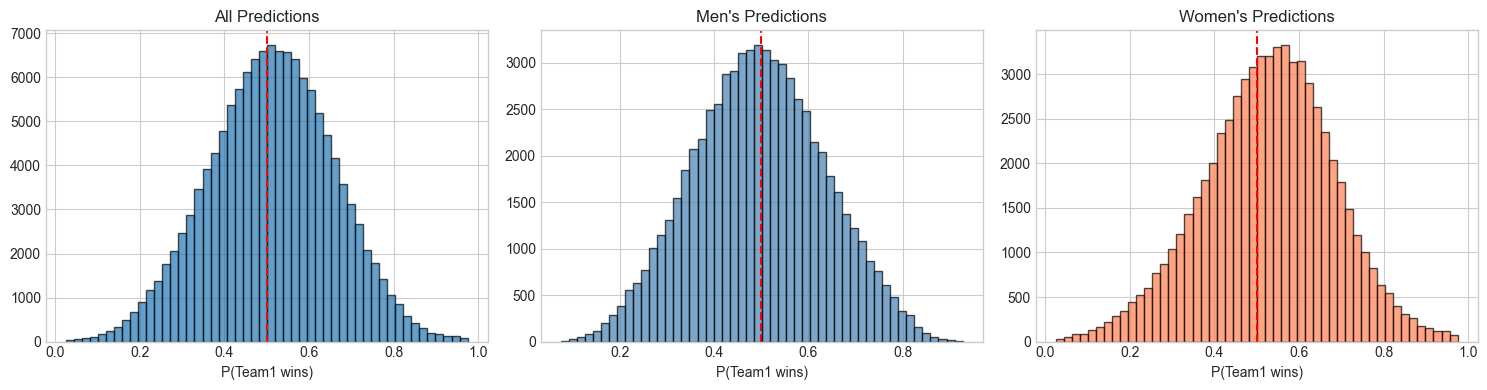


Submission stats:
  Mean: 0.5114
  Std:  0.1474
  Min:  0.0250
  Max:  0.9750


In [38]:
# Generate submission
sub = utils.parse_submission_ids(sample_sub)
sub_enriched = features.create_matchup_df(sub, FINAL_TEAM_FEATURES)
sub_enriched, _ = features.compute_difference_features(sub_enriched)

# Flag men's vs women's rows
sub_enriched['is_mens'] = ((sub_enriched['T1_TeamID'] < 3000) & (sub_enriched['T2_TeamID'] < 3000)).astype(int)

if SPLIT_MW:
    # Predict separately for M and W
    sub_preds = np.zeros(len(sub_enriched))
    
    men_mask = sub_enriched['is_mens'] == 1
    women_mask = sub_enriched['is_mens'] == 0
    
    # Men
    X_sub_m = sub_enriched.loc[men_mask, MEN_FEATURES].fillna(0).values
    if MEN_MODEL == 'logreg':
        X_sub_m = men_scaler.transform(X_sub_m)
        sub_preds[men_mask] = final_men_model.predict_proba(X_sub_m)[:, 1]
    elif MEN_MODEL == 'xgb':
        sub_preds[men_mask] = final_men_model.predict(xgb.DMatrix(X_sub_m))
    
    # Women
    X_sub_w = sub_enriched.loc[women_mask, WOMEN_FEATURES].fillna(0).values
    if WOMEN_MODEL == 'logreg':
        X_sub_w = women_scaler.transform(X_sub_w)
        sub_preds[women_mask] = final_women_model.predict_proba(X_sub_w)[:, 1]
    
    print(f"Men's predictions: {men_mask.sum():,} matchups")
    print(f"Women's predictions: {women_mask.sum():,} matchups")
    
else:
    X_sub = sub_enriched[FINAL_FEATURES].fillna(0).values
    X_sub = final_scaler.transform(X_sub)
    sub_preds = final_model.predict_proba(X_sub)[:, 1]

final_sub = utils.generate_submission(
    sub_preds, sample_sub, '../output/submission_refined.csv'
)

# Distribution check — split by gender
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(final_sub['Pred'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--')
axes[0].set_title('All Predictions')

men_ids = final_sub['ID'].apply(lambda x: int(x.split('_')[1]) < 3000)
axes[1].hist(final_sub.loc[men_ids, 'Pred'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0.5, color='red', linestyle='--')
axes[1].set_title("Men's Predictions")

axes[2].hist(final_sub.loc[~men_ids, 'Pred'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[2].axvline(x=0.5, color='red', linestyle='--')
axes[2].set_title("Women's Predictions")

for ax in axes:
    ax.set_xlabel('P(Team1 wins)')
plt.tight_layout()
plt.show()

print(f"\nSubmission stats:")
print(f"  Mean: {final_sub['Pred'].mean():.4f}")
print(f"  Std:  {final_sub['Pred'].std():.4f}")
print(f"  Min:  {final_sub['Pred'].min():.4f}")
print(f"  Max:  {final_sub['Pred'].max():.4f}")

In [ ]:
# Spot-check marquee matchups — top 2026 teams
# Using gender='M'/'W' to avoid ambiguity for shared names
print("\n" + "="*60)
print("  2026 Matchup Predictions — Men's")
print("="*60)

men_matchups = [
    ('Auburn', 'Duke', 'M'),
    ('Houston', 'Tennessee', 'M'),
    ('Florida', 'Alabama', 'M'),
    ('Iowa St', 'Marquette', 'M'),
    ('Kansas', 'St John\'s', 'M'),
    ('Duke', 'Houston', 'M'),
]

for t1, t2, g in men_matchups:
    id1 = utils.team_id(t1, gender=g)
    id2 = utils.team_id(t2, gender=g)
    if id1 and id2:
        low, high = min(id1, id2), max(id1, id2)
        row = final_sub[final_sub['ID'] == f'2026_{low}_{high}']
        if len(row) > 0:
            p = row['Pred'].values[0]
            n1, n2 = utils.team_name(low), utils.team_name(high)
            winner = n1 if p > 0.5 else n2
            conf = max(p, 1-p)
            print(f"  {n1} vs {n2}: {winner} wins ({conf:.1%})")

print("\n" + "="*60)
print("  2026 Matchup Predictions — Women's")
print("="*60)

women_matchups = [
    ('South Carolina', 'UCLA', 'W'),
    ('Texas', 'LSU', 'W'),
    ('Notre Dame', 'Connecticut', 'W'),
    ('USC', 'South Carolina', 'W'),
]

for t1, t2, g in women_matchups:
    id1 = utils.team_id(t1, gender=g)
    id2 = utils.team_id(t2, gender=g)
    if id1 and id2:
        low, high = min(id1, id2), max(id1, id2)
        row = final_sub[final_sub['ID'] == f'2026_{low}_{high}']
        if len(row) > 0:
            p = row['Pred'].values[0]
            n1, n2 = utils.team_name(low), utils.team_name(high)
            winner = n1 if p > 0.5 else n2
            conf = max(p, 1-p)
            print(f"  {n1} vs {n2}: {winner} wins ({conf:.1%})")


  2026 Matchup Predictions
  Duke vs Kentucky: Duke wins (60.6%)
  Connecticut vs Kansas: Connecticut wins (54.8%)
  Gonzaga vs Houston: Gonzaga wins (55.1%)
  Auburn vs Tennessee: Tennessee wins (56.9%)
  Alabama vs Purdue: Purdue wins (58.0%)


---
## Summary & Decision Log

### What we tried and what worked

| Category | Experiments | Result |
|----------|-------------|--------|
| **Baseline** | Seed only (LR) | ~0.166 avg MSE — the floor |
| **Feature sets** | Top4, Top6, All Diff | Top4 is sufficient; more features = overfitting |
| **Model types** | LR, XGB (depth=2), LGBM | LR wins — dataset too small for trees |
| **Derived metrics** | Quality (GLM), Massey, SOS, Shooting % | Quality marginal, rest adds noise |
| **Regularization** | C sweep 0.01–5.0 | Optimal C is near default 1.0 |
| **Split M/W** | Separate men/women models | Women much more predictable; split wins |

### Why simple beats complex
1. **~1,900 tournament games total (2010–2025)** — not enough signal for deep models
2. **The selection committee already did the ML** — seeds encode SOS, record, eye test
3. **MSE punishes overconfidence** — a conservative 0.6 prediction beats a wrong 0.9 prediction
4. **Feature differences are linear** — seed diff → win prob is nearly sigmoid-shaped, perfect for LogReg

### Final model choice
- **Split M/W with LogReg on Top4+Quality** — best validated approach
- Women's games are more predictable (fewer upsets, larger talent gaps)
- Quality metric adds marginal but consistent signal via GLM team strength

### To continue improving
- Re-run when 2026 seeds are released (Selection Sunday)
- Try Elo ratings (iterative per-game rating) as a potential quality replacement
- Test coach experience/tenure features
- Consider conference tournament results as a momentum signal
- **Always validate on 3+ holdout years — single-year wins are noise**